# TurtleBot3 - Obstacle avoidance

Scenario: `scenarios/turtlebot3_obstacle.yaml`

This notebook analyses the normative reasoning of a TurtleBot3 when avoiding obstacles detected with LiDAR, in individual and multi-robot mode, and shows the argumentation attack diagram.

- **w1**: obstacle < 30 cm (danger)
- **w2**: obstacle 30-60 cm (caution)
- **w3**: no obstacle
- **w4**: robot in motion
- **w5 / w6**: peer reports clear / obstacle
- **w7 / w8**: peer trusted / untrusted

*Scenario originally authored by Diego Pastrana (University of Leon); edited and provided with Jupyter notebooks in this repository.*


In [15]:
PATH = "../scenarios/turtlebot3_obstacle.yaml"

## Imports and utilities

In [16]:
import sys, os
sys.path.append(os.path.abspath(".."))

from jiminy.engine import Jiminy
from jiminy.yaml_loader import load_scenario
from jiminy.visualization.argumentation_visualizer import ArgumentationVisualizer

def load(path=PATH):
    (pf, norms, contrariness, priorities, context_desc, norm_desc,
     contrariness_desc, priority_desc, base_priorities, meta_priorities) = load_scenario(path)
    return Jiminy(norms, contrariness, priorities, context_desc, norm_desc,
                  contrariness_desc, priority_desc, base_priorities, meta_priorities)

def run(facts, semantics="priority"):
    jim = load()
    args = jim.generate_arguments(facts)
    accepted, rejected = jim.compute_extension(args, semantics=semantics)
    decisions = sorted(a.hd for a in accepted if a.hd.startswith("d") or a.hd.startswith("p"))
    return decisions, jim, args, accepted, rejected

## Load the scenario

In [17]:
jim = load()
print("Facts:", sorted(load_scenario(PATH)[0]))
print("Number of norms:", len(jim.norms))
print("Priorities:")
for k, v in sorted(jim.priorities.items()):
    print(f"  {k:<18} {v:>3}  - {jim.priority_desc.get(k, '')}")

[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
Facts: ['w1', 'w2', 'w3', 'w4', 'w5', 'w6', 'w7', 'w8']
Number of norms: 13
Priorities:
  d_ignore_peer        8  - Ignoring untrusted peer has high priority for security.
  d_move               2  - Free movement has the lowest priority.
  d_prefer_safe        7  - Conservative default has high priority.
  d_slow_down          6  - Slowing down has high priority — caution zone.
  d_stop              10  - Stopping has the highest priority — immediate safety.
  d_use_own_sensors    8  - Own sensor data is highly trusted when peer is compromised.
  p_continue           3  - Continuing movement has low priority compared to safety.


## Decision - Individual mode

Depending on the own obstacle distance, the `priority` semantics recommends:
- `w1 w4` -> **d_stop** (close obstacle)
- `w2 w4` -> **d_slow_down** (caution zone)
- `w3 w4` -> **d_move** (no obstacle)

In [18]:
cases = {
    "Close obstacle": ['w1', 'w4'],
    "Caution zone": ['w2', 'w4'],
    "No obstacle": ['w3', 'w4']}

for name, facts in cases.items():
    decisions, _, _, _, _ = run(facts, "priority")
    print(f"{name:28s} {facts}  ->  {decisions}")

[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000105 seconds
Close obstacle               ['w1', 'w4']  ->  ['d_prefer_safe', 'd_stop']
[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000069 seconds
Caution zone                 ['w2', 'w4']  ->  ['d_prefer_safe', 'd_slow_down']
[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000079 seconds
No obstacle                  ['w3', 'w4']  ->  ['d_move', 'd_prefer_safe']


## Decision - Multi-robot mode

With shared peer information, the decision is still driven by the own LiDAR (safety first).

In [19]:
cases = {
    "Own obstacle + peer clear": ['w1', 'w4', 'w5'],
    "Own clear + peer obstacle": ['w3', 'w4', 'w6'],
    "Both with obstacle": ['w1', 'w4', 'w6'],
    "Both clear": ['w3', 'w4', 'w5']}

for name, facts in cases.items():
    decisions, _, _, _, _ = run(facts, "priority")
    print(f"{name:28s} {facts}  ->  {decisions}")

[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000053 seconds
Own obstacle + peer clear    ['w1', 'w4', 'w5']  ->  ['d_prefer_safe', 'd_stop']
[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000069 seconds
Own clear + peer obstacle    ['w3', 'w4', 'w6']  ->  ['d_move', 'd_prefer_safe']
[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000077 seconds
Both with obstacle           ['w1', 'w4', 'w6']  ->  ['d_prefer_safe', 'd_stop']
[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000067 seconds
Both clear                   ['w3', 'w4', 'w5']  ->  ['d_move', 'd_prefer_saf

## Narrative explanation

In [20]:
facts = ['w1', 'w4']
decisions, jim, args, accepted, rejected = run(facts, "priority")
print(jim.explain(accepted, rejected, facts, semantics="priority"))

[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000060 seconds
CONTEXT ANALYSIS
------------------------------------------------------------
 - w1
 - w4

GENERATED ARGUMENTS
------------------------------------------------------------
 - ('w1',) ⇒ i_danger (Institutional fact, stakeholder=Safety)
 - ('i_danger', 'w4') ⇒ d_stop (Obligation, stakeholder=Safety)
 - () ⇒ d_prefer_safe (Obligation, stakeholder=Manufacturer)

DETECTED CONFLICTS
------------------------------------------------------------
 - d_stop conflicts with: d_move, d_slow_down
 - d_prefer_safe conflicts with: d_move

PRIORITY EVALUATION
------------------------------------------------------------
 - d_stop: 10
 - d_prefer_safe: 7

ACCEPTED ARGUMENTS
------------------------------------------------------------
 ✔ i_danger accepted (institutional fact)
 ✔ d_stop accepted (stakeholder=Safety, priority=10)
 ✔ d_prefer

## Argumentation attack diagram

Activating the full context lets all contrary decisions coexist, so every
attack (chi, red) and defeat (>, dashed blue) relation of the argumentation
framework is drawn. Nodes with a double border are accepted by the `priority` semantics.

[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000150 seconds
[Visualizer] Rendering graph → tb_obstacle_af.png


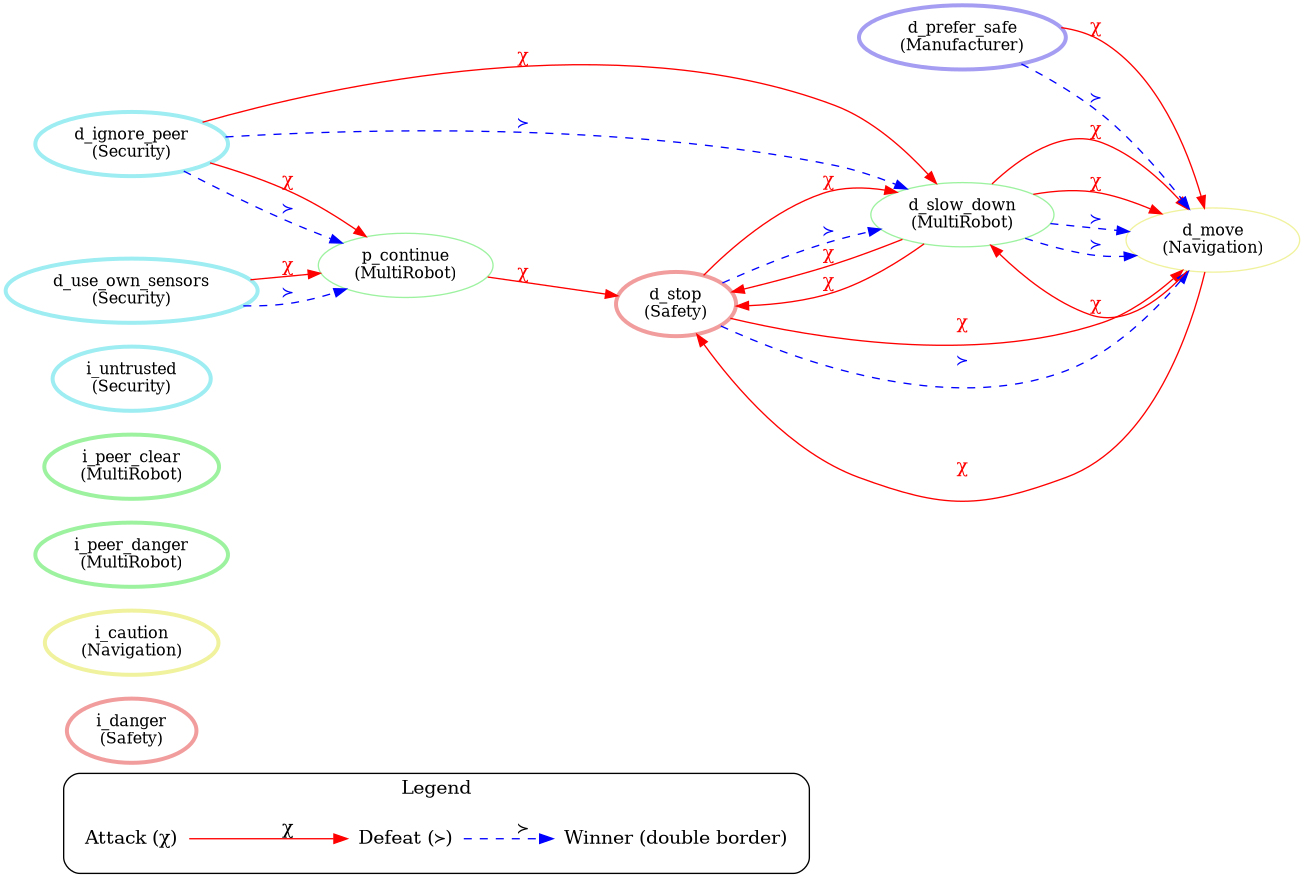


=== Attack relations (chi) present ===
  d_stop  <->  d_move
  d_stop  <->  d_slow_down
  d_slow_down  <->  d_move
  d_slow_down  <->  d_stop
  d_move  <->  d_stop
  d_move  <->  d_slow_down
  d_ignore_peer  <->  d_slow_down
  d_ignore_peer  <->  p_continue
  d_use_own_sensors  <->  p_continue
  p_continue  <->  d_stop
  d_prefer_safe  <->  d_move


In [21]:
from IPython.display import Image, display

jim = load()
all_facts = list(load_scenario(PATH)[0])
args = jim.generate_arguments(all_facts)
accepted, rejected = jim.compute_extension(args, semantics="priority")

av = ArgumentationVisualizer()
av.build_graph(arguments=args, winners={a.hd for a in accepted},
                priorities=jim.priorities, contrariness=jim.contrariness)
name = "tb_obstacle_af"
av.render(name)
display(Image(filename=f"{name}.png"))

print("\n=== Attack relations (chi) present ===")
for src, contraries in jim.contrariness.items():
    for c in contraries:
        if c in {a.hd for a in args}:
            print(f"  {src}  <->  {c}")

## Graphviz Advanced Exports - Reasoning graph

Approach taken from the `jiminy_example` notebook (`export_reasoning_graph`, the 2nd figure).
It shows the reasoning dependency chain: facts (blue) -> institutional facts (green) ->
decisions (orange = accepted, gray = rejected), with the norm descriptions as labels.
A color legend is embedded in the graph.

[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
[INFO] Base priorities loaded: 0
[INFO] Meta-priority rules loaded: 0
>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000326 seconds


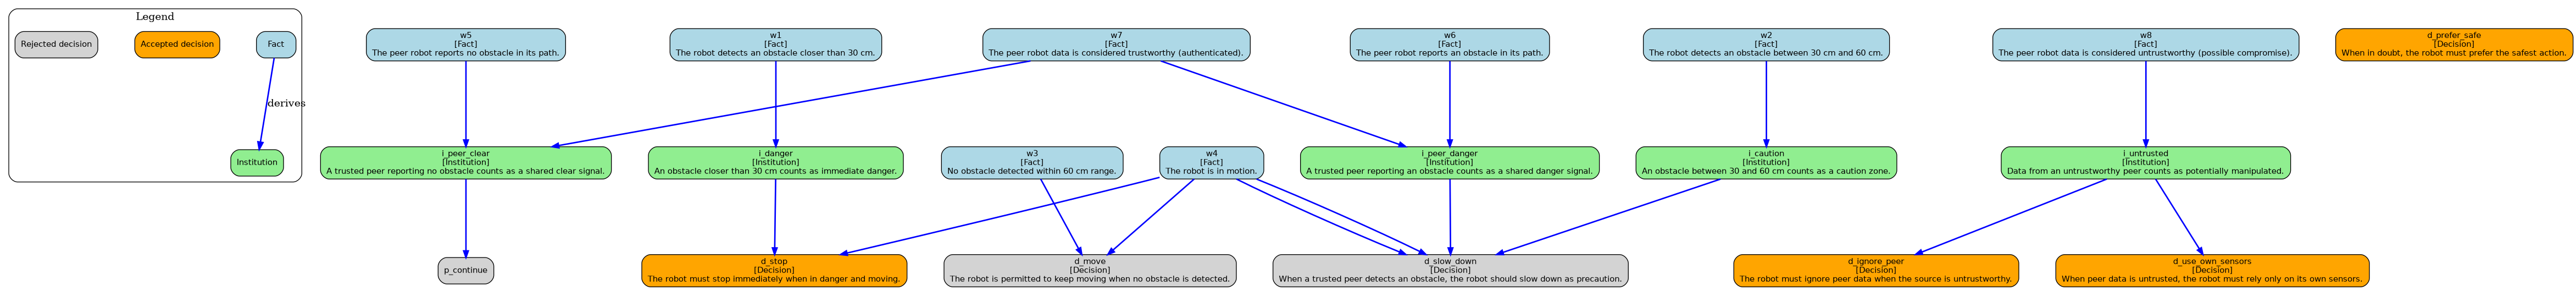

In [22]:
# --- Graphviz Advanced Exports: reasoning graph (2nd figure of jiminy_example) ---
from graphviz import Digraph
from IPython.display import Image, display

# Build a label for each atom, attaching its textual description
def build_label(atom):
    if atom.startswith("w"):
        return f"{atom}\n[Fact]\n{jim.context_desc.get(atom,'')}"
    if atom.startswith("i"):
        return f"{atom}\n[Institution]\n{jim.norm_desc.get(atom,'')}"
    if atom.startswith("d"):
        return f"{atom}\n[Decision]\n{jim.norm_desc.get(atom,'')}"
    return atom

def export_reasoning_graph(path):
    g = Digraph("Jiminy Reasoning", engine="dot")
    g.attr(rankdir="TB", ranksep="1.4", nodesep="0.7", splines="spline")
    g.attr("node", shape="box", style="rounded,filled", fontname="Helvetica", fontsize="11")

    # Color legend so the diagram is easier to read
    with g.subgraph(name="cluster_legend") as legend:
        legend.attr(label="Legend", style="rounded", color="black", fontsize="14")
        legend.node("lg_fact", "Fact", fillcolor="lightblue")
        legend.node("lg_inst", "Institution", fillcolor="lightgreen")
        legend.node("lg_acc", "Accepted decision", fillcolor="orange")
        legend.node("lg_rej", "Rejected decision", fillcolor="lightgray")
        legend.edge("lg_fact", "lg_inst", color="blue", penwidth="2", label="derives")

    winners = {a.hd for a in accepted}
    facts, inst, decisions = set(), set(), set()
    edges = []

    # Collect nodes and derivation edges from every argument
    for a in args_final:
        head = a.hd
        if head.startswith("w"): facts.add(head)
        elif head.startswith("i"): inst.add(head)
        elif head.startswith("d"): decisions.add(head)

        body = getattr(a.origin_norm, "body", [])
        for b in body:
            edges.append((b, head))
            if b.startswith("w"): facts.add(b)
            elif b.startswith("i"): inst.add(b)
            elif b.startswith("d"): decisions.add(b)

    # Color nodes by type (facts / institutions / decisions)
    for w in facts: g.node(w, label=build_label(w), fillcolor="lightblue")
    for i in inst: g.node(i, label=build_label(i), fillcolor="lightgreen")
    for d in decisions:
        color = "orange" if d in winners else "lightgray"
        g.node(d, label=build_label(d), fillcolor=color)

    # Draw the derivation edges (body -> head)
    for a, b in edges: g.edge(a, b, color="blue", penwidth="2", arrowsize="0.9")

    g.render(path, format="png", cleanup=True)
    return f"{path}.png"

# Rebuild the framework over the full context
jim = load()
all_facts = list(load_scenario(PATH)[0])
args_final = jim.generate_arguments(all_facts)
accepted, rejected = jim.compute_extension(args_final, semantics="priority")

display(Image(filename=export_reasoning_graph("tb_obstacle_reasoning")))